# YOLOv8 TXT Segmentation Workflow

This notebook builds a segmentation dataset using YOLO TXT polygon labels and trains YOLOv8-seg directly.

In [ ]:
from ultralytics import YOLO
from glob import glob
import cv2
import numpy as np
import os
import random
import shutil
import yaml
import matplotlib.pyplot as plt

In [ ]:

random.seed(42)

IMG_DIR = "data/images"
LABEL_DIR = "data/labels"
DATASET_DIR = "for_training"

TRAIN_RATIO = 0.7
VAL_RATIO = 0.2
TEST_RATIO = 0.1

CLASS_NAMES = ["filaments"]
assert abs((TRAIN_RATIO + VAL_RATIO + TEST_RATIO) - 1.0) < 1e-9

In [4]:
# 1) Build label lookup: image_core -> label_path
label_lookup = {}
for label_path in glob(os.path.join(LABEL_DIR, "*.txt")):
    base = os.path.splitext(os.path.basename(label_path))[0]
    # label file example: uuid-ch20_xxx_frame_001
    image_core = base.split("-", 1)[1] if "-" in base else base
    if image_core not in label_lookup:
        label_lookup[image_core] = label_path

img_files = sorted(glob(os.path.join(IMG_DIR, "*.png")))
random.shuffle(img_files)

n_total = len(img_files)
n_train = int(n_total * TRAIN_RATIO)
n_val = int(n_total * VAL_RATIO)

train_files = img_files[:n_train]
val_files = img_files[n_train:n_train + n_val]
test_files = img_files[n_train + n_val:]

splits = {
    "train": train_files,
    "val": val_files,
    "test": test_files
}

# If an image has no label, create an empty txt file to indicate "no mask".
CREATE_EMPTY_LABEL_FOR_MISSING = True

# Recreate output folders
if os.path.exists(DATASET_DIR):
    shutil.rmtree(DATASET_DIR)

for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(DATASET_DIR, "images", split), exist_ok=True)
    os.makedirs(os.path.join(DATASET_DIR, "labels", split), exist_ok=True)

missing = []
empty_label_created = 0
for split, files in splits.items():
    for img_path in files:
        img_name = os.path.basename(img_path)
        core = os.path.splitext(img_name)[0]

        dst_img = os.path.join(DATASET_DIR, "images", split, img_name)
        shutil.copy2(img_path, dst_img)

        dst_label = os.path.join(DATASET_DIR, "labels", split, core + ".txt")
        if core in label_lookup:
            # YOLO expects matching txt basename with image basename
            shutil.copy2(label_lookup[core], dst_label)
        else:
            missing.append((split, core))
            if CREATE_EMPTY_LABEL_FOR_MISSING:
                # Empty txt = valid negative sample (no object / no mask).
                with open(dst_label, "w", encoding="utf-8") as f:
                    f.write("")
                empty_label_created += 1

print(f"Total images: {n_total}")
for split, files in splits.items():
    print(f"{split}: {len(files)} images")
print(f"Missing labels: {len(missing)}")
print(f"Empty labels created (no mask): {empty_label_created}")
print("First 20 missing:")
for item in missing[:20]:
    print(item)

Total images: 515
train: 360 images
val: 103 images
test: 52 images
Missing labels: 222
Empty labels created (no mask): 222
First 20 missing:
('train', 'ch20_URA7_URA8_001-crop1_frame_055')
('train', 'ch20_URA7_URA8_001-crop1_frame_074')
('train', 'ch20_URA7_URA8_001-crop3_frame_005')
('train', 'ch20_URA7_URA8_002-crop4_frame_029')
('train', 'ch20_URA7_URA8_001-crop1_frame_034')
('train', 'ch20_URA7_URA8_001-crop1_frame_018')
('train', 'ch20_URA7_URA8_001-crop2_frame_038')
('train', 'ch20_URA7_URA8_001-crop2_frame_090')
('train', 'ch20_URA7_URA8_001-crop3_frame_067')
('train', 'ch20_URA7_URA8_001-crop1_frame_044')
('train', 'ch20_URA7_URA8_001-crop1_frame_080')
('train', 'ch20_URA7_URA8_001-crop3_frame_093')
('train', 'ch20_URA7_URA8_001-crop1_frame_091')
('train', 'ch20_URA7_URA8_001-crop2_frame_059')
('train', 'ch20_URA7_URA8_001-crop3_frame_055')
('train', 'ch20_URA7_URA8_001-crop3_frame_052')
('train', 'ch20_URA7_URA8_001-crop2_frame_095')
('train', 'ch20_URA7_URA8_001-crop2_frame_

In [5]:
# 2) Quick consistency check
for split in ["train", "val", "test"]:
    img_dir = os.path.join(DATASET_DIR, "images", split)
    lbl_dir = os.path.join(DATASET_DIR, "labels", split)

    imgs = set(os.path.splitext(f)[0] for f in os.listdir(img_dir) if f.endswith(".png"))
    lbls = set(os.path.splitext(f)[0] for f in os.listdir(lbl_dir) if f.endswith(".txt"))
    print(f"{split}: images={len(imgs)}, labels={len(lbls)}, usable={len(imgs & lbls)}")

train: images=360, labels=360, usable=360
val: images=103, labels=103, usable=103
test: images=52, labels=52, usable=52


In [6]:
# 3) Write data.yaml
data_yaml = {
    "path": DATASET_DIR,
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "nc": len(CLASS_NAMES),
    "names": CLASS_NAMES
}

yaml_path = os.path.join(DATASET_DIR, "data.yaml")
with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False, allow_unicode=True)

print("Saved:", yaml_path)
print(open(yaml_path, "r", encoding="utf-8").read())

Saved: for_training/data.yaml
path: for_training
train: images/train
val: images/val
test: images/test
nc: 1
names:
- filaments



In [8]:
# 4) Train YOLOv8-seg with TXT labels
!yolo task=segment mode=train model=yolov8s-seg.pt data=for_training/data.yaml epochs=100 imgsz=640 batch=8 name=train_txt_run

Ultralytics 8.4.24 🚀 Python-3.11.15 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070, 12002MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=for_training/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_txt_run2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

In [10]:
# 5) Validate best weights
!yolo task=segment mode=val model=runs/segment/train_txt_run/weights/best.pt data=for_training/data.yaml

Ultralytics 8.4.24 🚀 Python-3.11.15 torch-2.10.0+cu128 CUDA:0 (NVIDIA GeForce RTX 4070, 12002MiB)
YOLOv8s-seg summary (fused): 86 layers, 11,779,987 parameters, 0 gradients, 39.9 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1783.9±680.0 MB/s, size: 13.2 KB)
val: Scanning /home/chenfeng/Documents/biohackathon/work2/for_training/labels/val.cache... 103 images, 46 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 103/103 36.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 7.3it/s 1.0s0.1s
                   all        103         57      0.707      0.888      0.827      0.374      0.767      0.772       0.81      0.323
Speed: 1.6ms preprocess, 4.2ms inference, 0.0ms loss, 0.4ms postprocess per image
Results saved to /home/chenfeng/Documents/biohackathon/work2/runs/segment/val
💡 Learn more at https://docs.ultralytics.com/modes/val


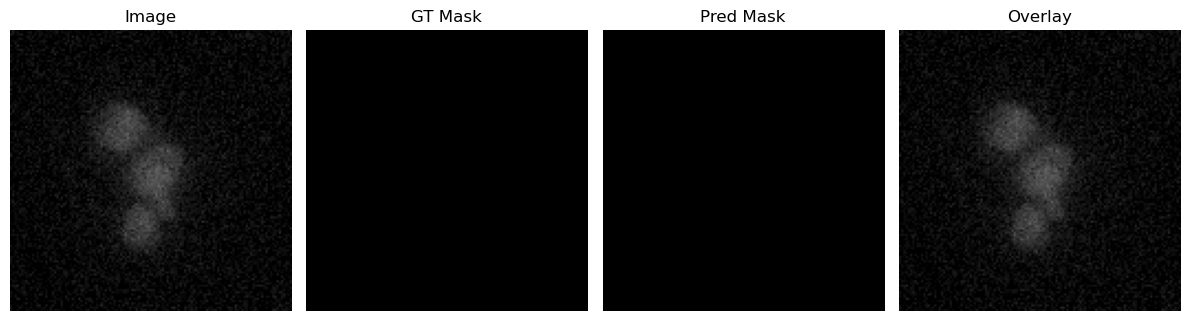

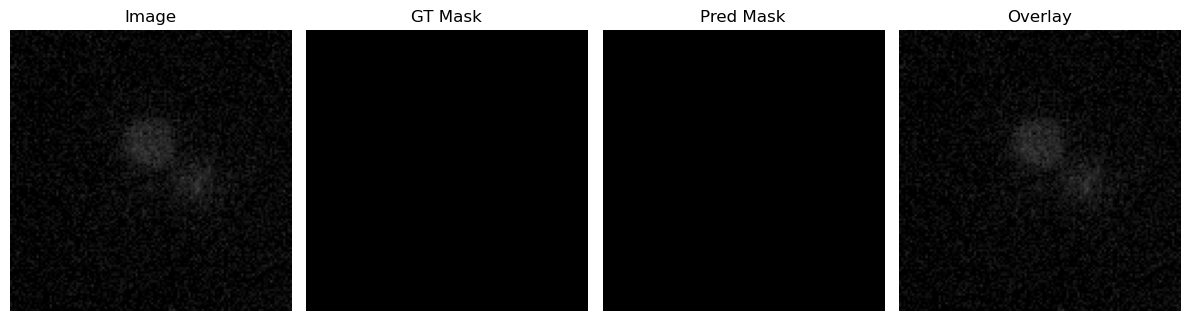

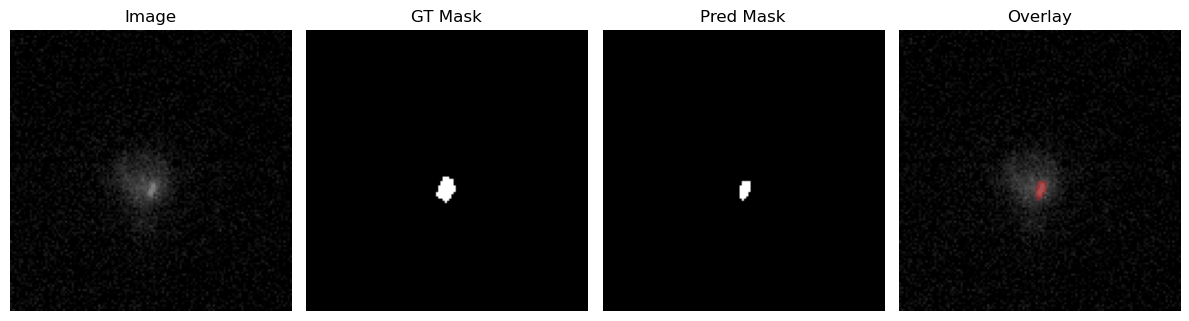

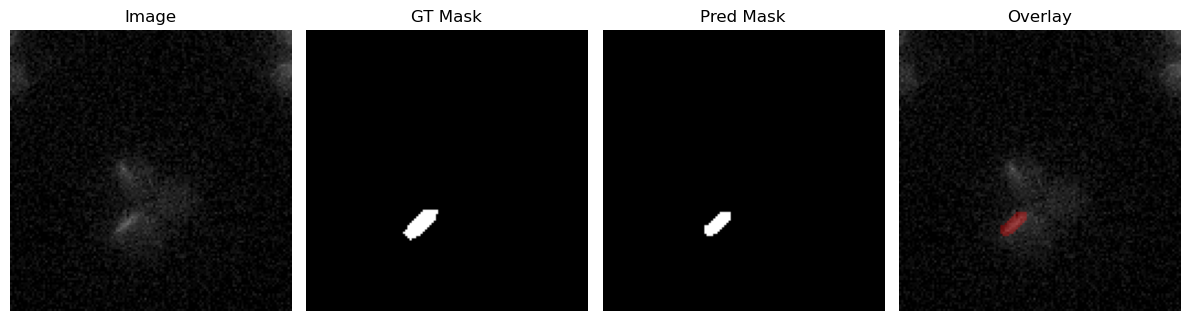

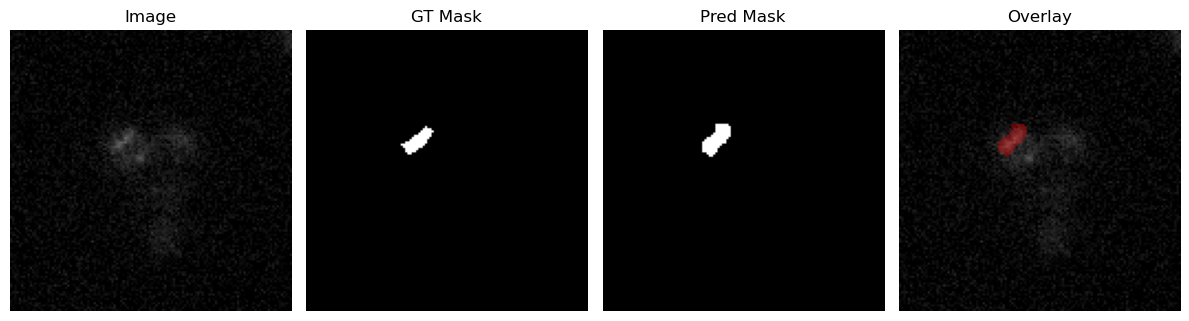

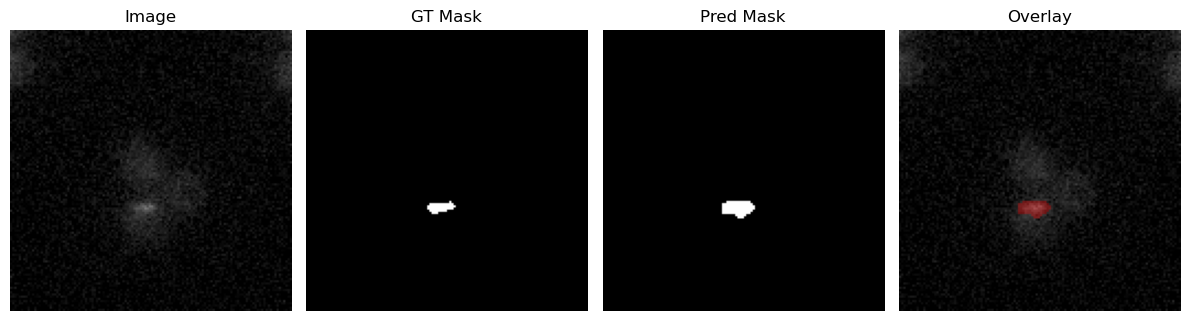

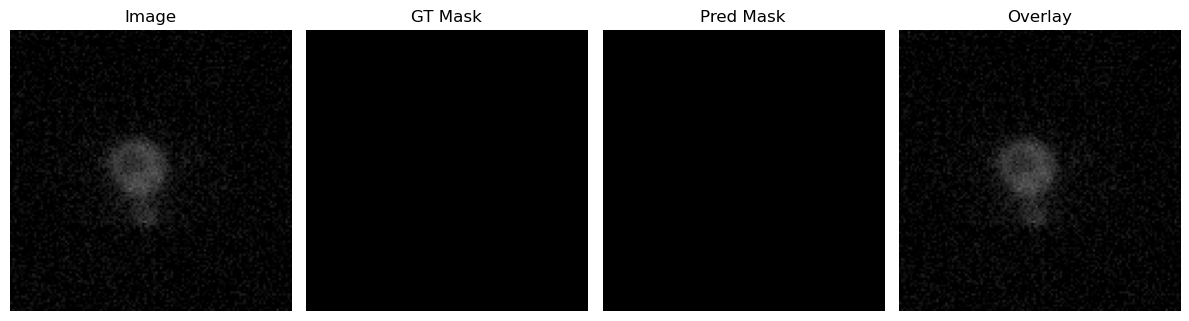

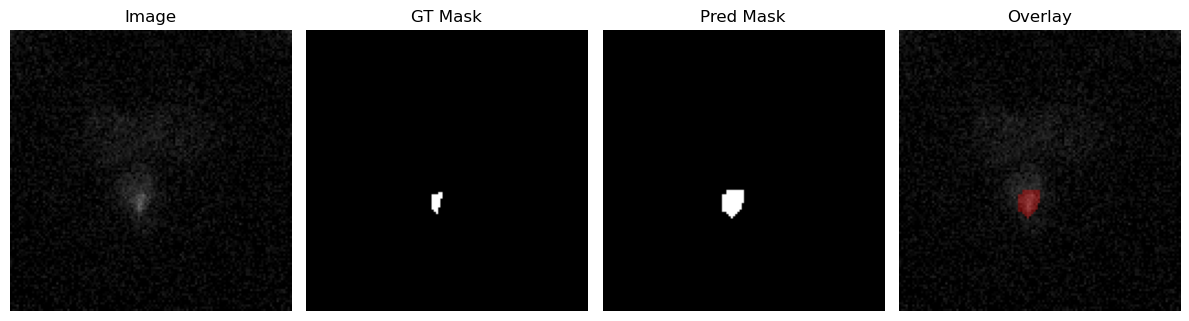

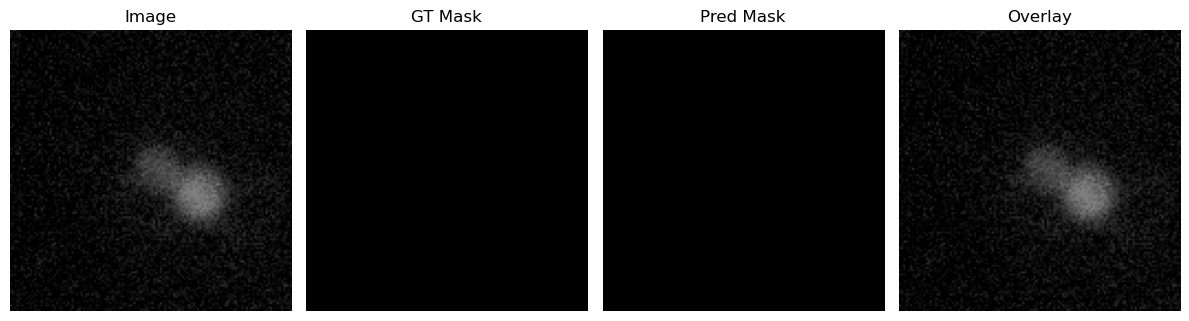

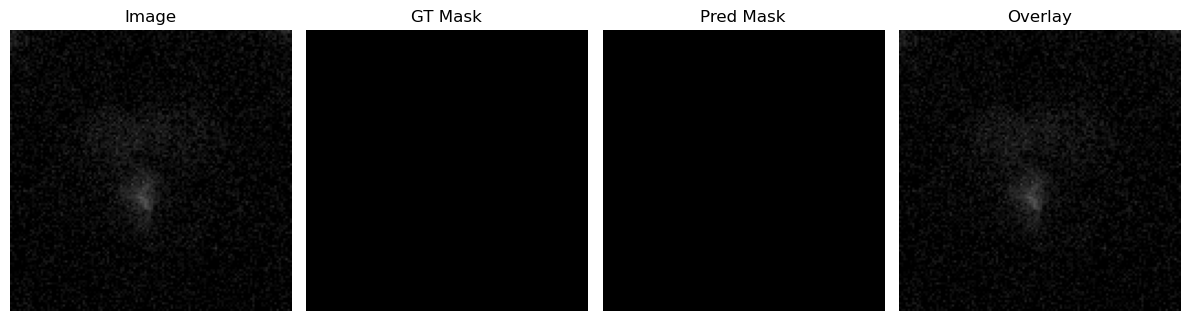

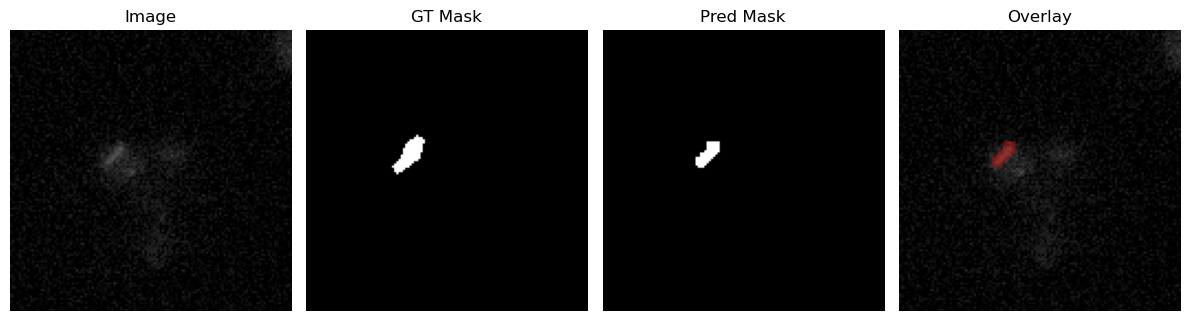

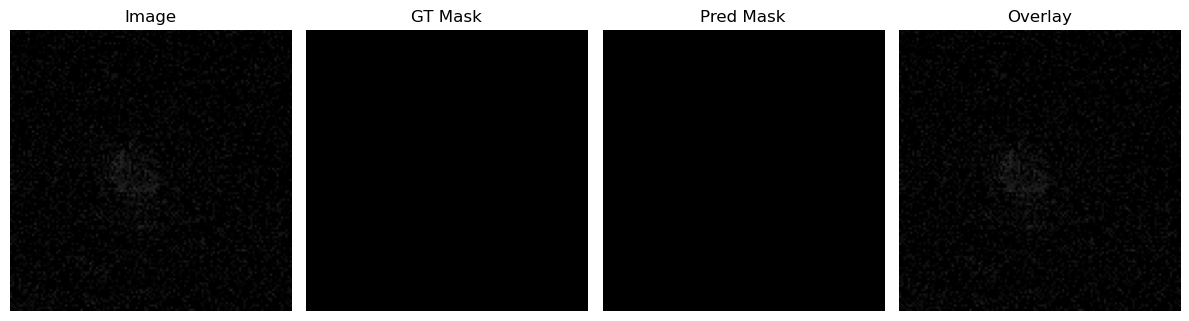

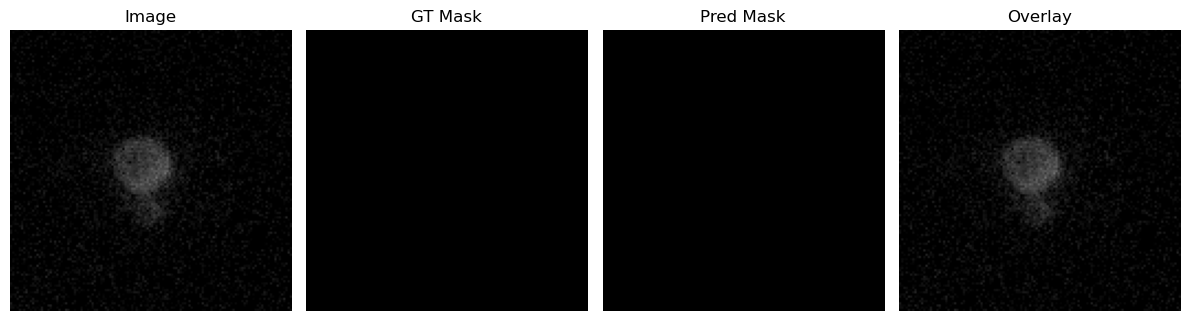

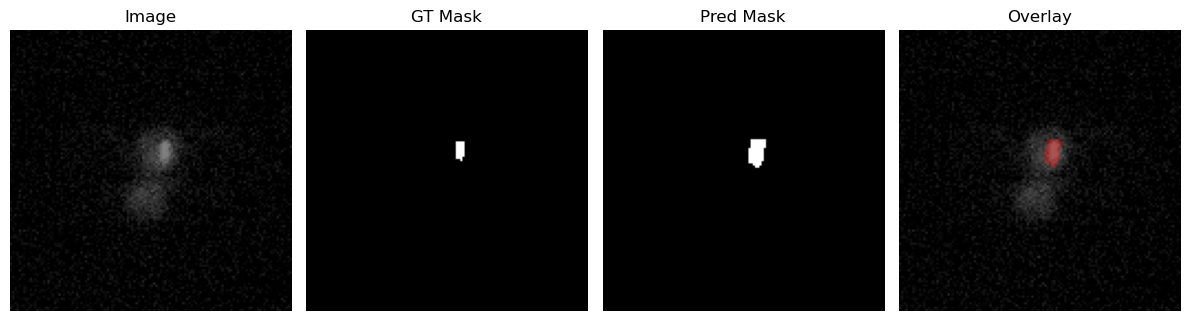

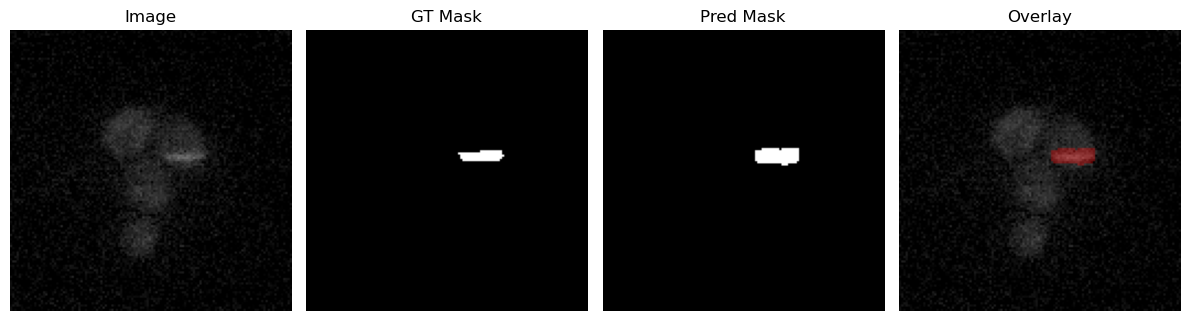

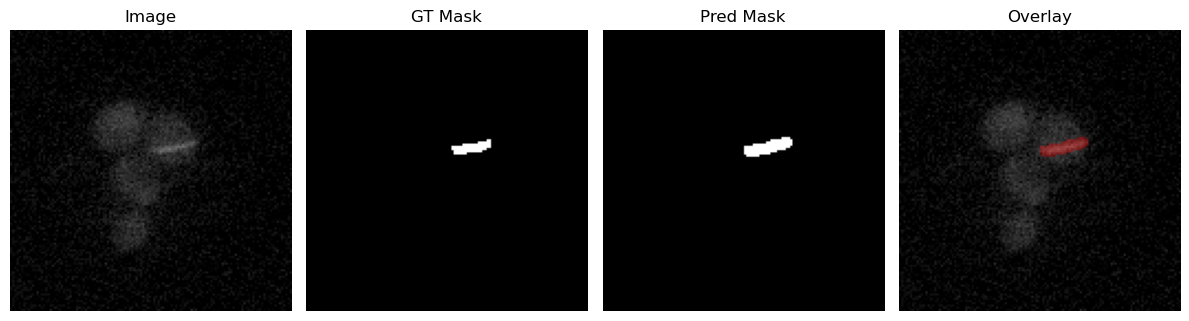

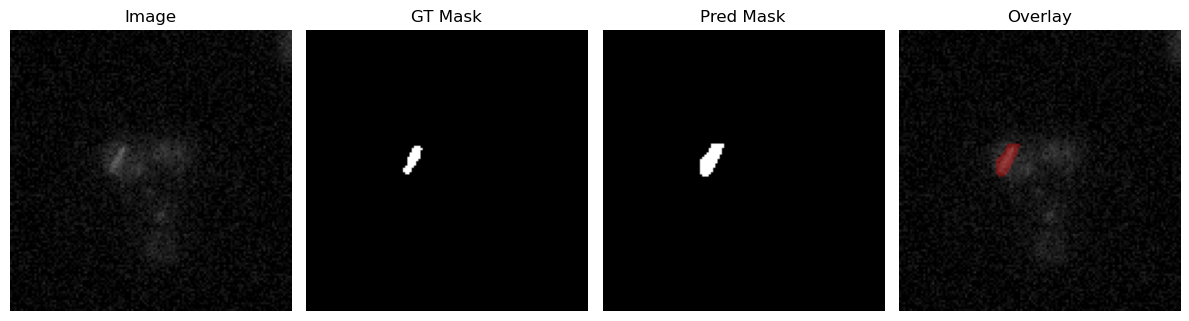

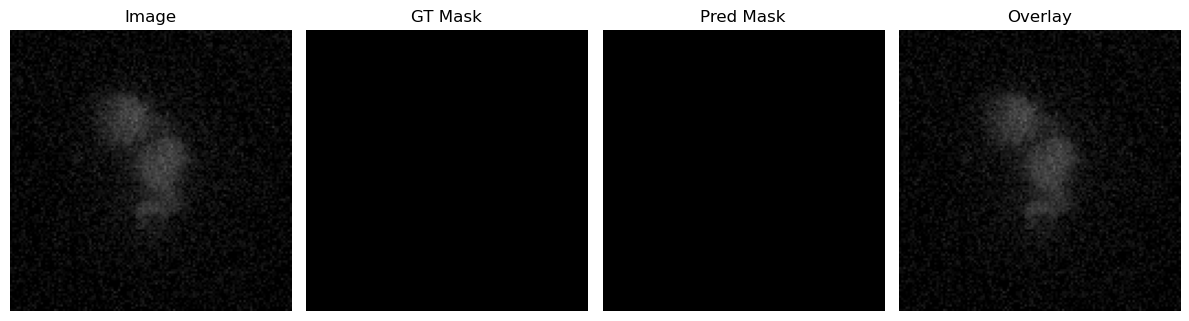

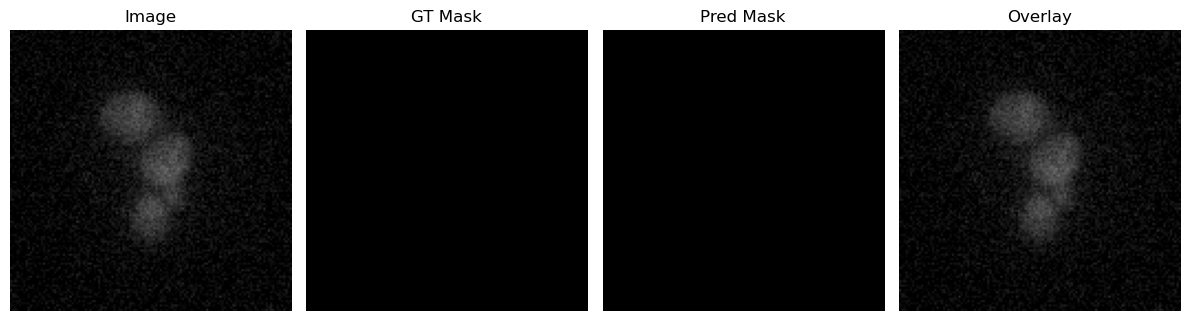

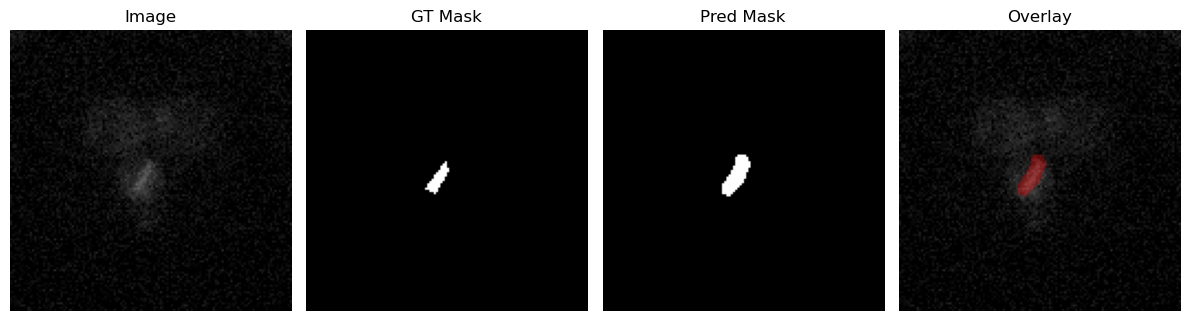

In [ ]:

MODEL_PATH = "runs/segment/train_txt_run/weights/best.pt"
TEST_IMG_DIR = "for_training/images/test"
TEST_LBL_DIR = "for_training/labels/test"
NUM_SHOW =20

if not os.path.exists(MODEL_PATH):
    raise FileNotFoundError(f"Model not found: {MODEL_PATH}，Please run the training cell first.")

model = YOLO(MODEL_PATH)
test_images = sorted([f for f in os.listdir(TEST_IMG_DIR) if f.endswith('.png')])
if len(test_images) == 0:
    raise RuntimeError("Test set is empty. Please run the dataset build cell first.")

def txt_polygons_to_mask(txt_path, h, w):
    mask = np.zeros((h, w), dtype=np.uint8)
    if not os.path.exists(txt_path):
        return mask
    with open(txt_path, "r", encoding="utf-8") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 7:
                continue
            coords = np.array(list(map(float, parts[1:])), dtype=np.float32)
            pts = np.stack([coords[::2] * w, coords[1::2] * h], axis=1).astype(np.int32)
            if len(pts) >= 3:
                cv2.fillPoly(mask, [pts], 1)
    return mask

show_list = random.sample(test_images, k=min(NUM_SHOW, len(test_images)))

for img_name in show_list:
    img_path = os.path.join(TEST_IMG_DIR, img_name)
    lbl_path = os.path.join(TEST_LBL_DIR, os.path.splitext(img_name)[0] + ".txt")

    bgr = cv2.imread(img_path)
    h, w = bgr.shape[:2]
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    gt_mask = txt_polygons_to_mask(lbl_path, h, w)

    res = model(img_path, verbose=False)[0]
    pred_mask = np.zeros((h, w), dtype=np.uint8)
    if res.masks is not None and res.masks.xyn is not None:
        for poly in res.masks.xyn:
            pts = np.stack([poly[:, 0] * w, poly[:, 1] * h], axis=1).astype(np.int32)
            if len(pts) >= 3:
                cv2.fillPoly(pred_mask, [pts], 1)

    overlay = rgb.copy().astype(np.float32)
    overlay[pred_mask == 1] = [255.0, 0.0, 0.0]
    blend = (0.65 * rgb.astype(np.float32) + 0.35 * overlay).astype(np.uint8)

    plt.figure(figsize=(12, 3.5))
    plt.subplot(1, 4, 1)
    plt.imshow(rgb)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(gt_mask, cmap="gray")
    plt.title("GT Mask")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("Pred Mask")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(blend)
    plt.title("Overlay")
    plt.axis("off")

    plt.tight_layout()
    plt.show()